# 01 - Exploratory Data Analysis
### Phishing URL Detector — PhiUSIIL Dataset

Goal: understand the dataset structure, class balance, and which features most strongly differentiate phishing URLs from legitimate ones.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/raw/Phishing_URL_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaciÃ³n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


## 1. Basic Info & Data Quality

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

In [4]:
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate URLs:", df['URL'].duplicated().sum())

Missing values:
 Series([], dtype: int64)

Duplicate URLs: 425


In [5]:
# Drop duplicate URLs
before = df.shape[0]
df = df.drop_duplicates(subset='URL').reset_index(drop=True)
print(f"Dropped {before - df.shape[0]} duplicate rows. New shape: {df.shape}")

Dropped 425 duplicate rows. New shape: (235370, 56)


## 2. Label Distribution

**Note:** `label` = 1 -> legitimate, `label` = 0 -> phishing (verified by inspecting sample URLs).

In [ ]:
label_counts = df['label'].value_counts()
label_pct = df['label'].value_counts(normalize=True) * 100

print(label_counts)
print(label_pct)

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(data=df, x='label', palette=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_xticklabels(['Phishing (0)', 'Legitimate (1)'])
ax.set_title("Class Distribution")
plt.show()

## 3. Key Feature Distributions: Phishing vs Legitimate

C:\Users\nopj2\AppData\Local\Temp\ipykernel_17556\1788485521.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, ax=axes[i], palette=['#e74c3c', '#2ecc71'])
C:\Users\nopj2\AppData\Local\Temp\ipykernel_17556\1788485521.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Phishing', 'Legitimate'])
C:\Users\nopj2\AppData\Local\Temp\ipykernel_17556\1788485521.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, ax=axes[i], palette=['#e74c3c', '#2ecc71'])
C:\Users\nopj2\AppData\Local\Temp\ipykernel_17556\1788485521.py:13: UserWarnin

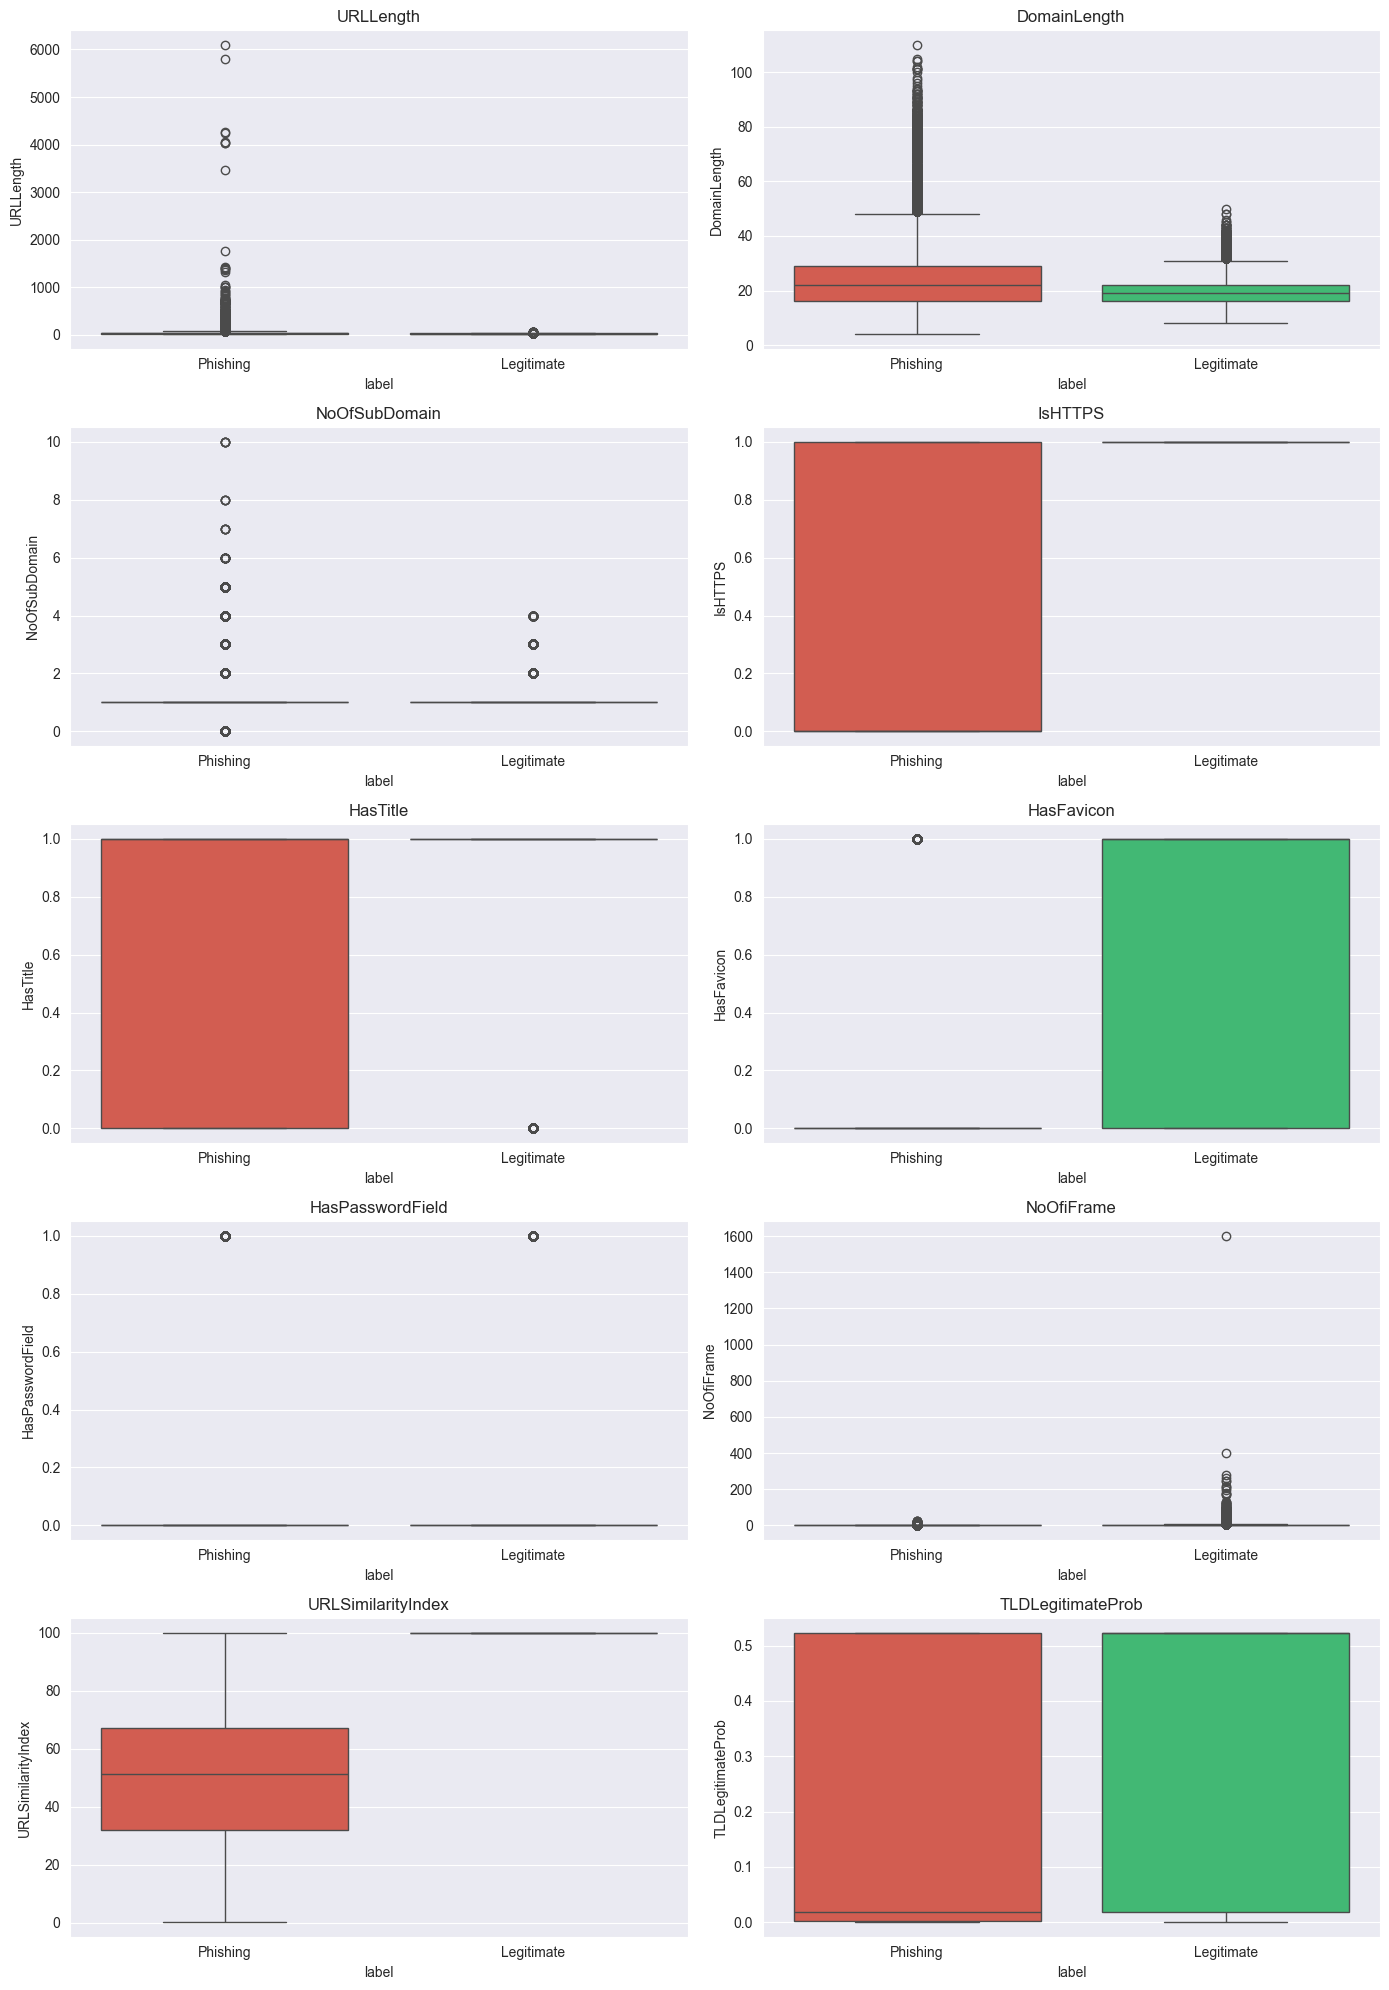

In [6]:
key_features = [
    'URLLength', 'DomainLength', 'NoOfSubDomain', 'IsHTTPS',
    'HasTitle', 'HasFavicon', 'HasPasswordField', 'NoOfiFrame',
    'URLSimilarityIndex', 'TLDLegitimateProb'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='label', y=col, ax=axes[i], palette=['#e74c3c', '#2ecc71'])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Phishing', 'Legitimate'])

plt.tight_layout()
plt.show()

## 4. Binary/Flag Features — Rate Comparison

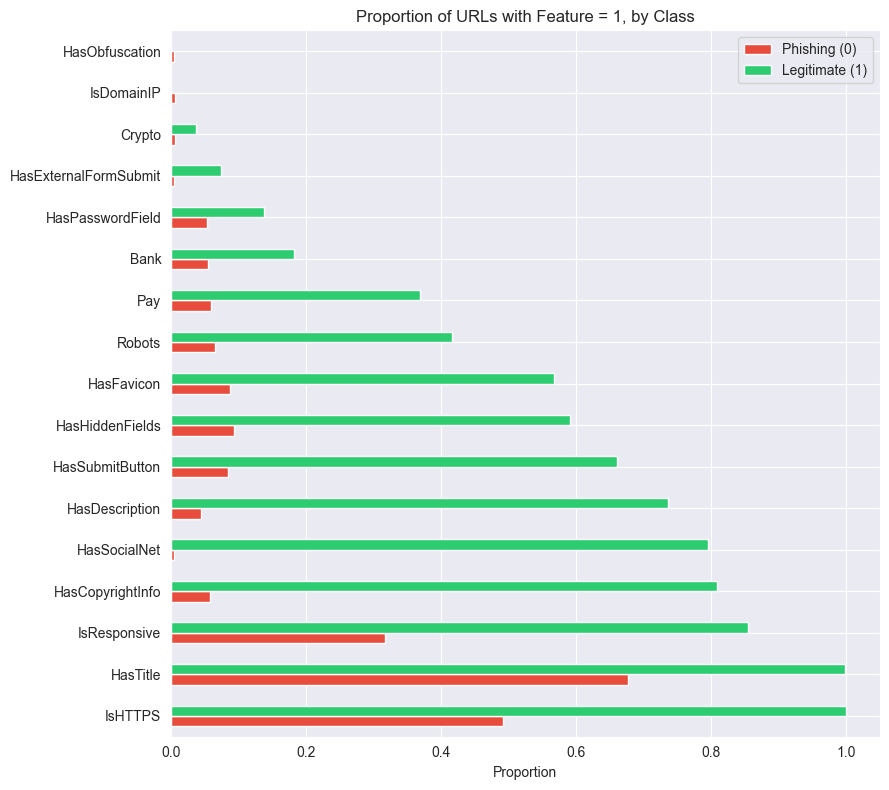

,Phishing (0),Legitimate (1)
IsHTTPS,0.491226,1.000000
HasTitle,0.677238,0.998754
IsResponsive,0.317041,0.854364
HasCopyrightInfo,0.057242,0.808239
HasSocialNet,0.005084,0.794557
HasDescription,0.044061,0.736633
HasSubmitButton,0.084391,0.660882
HasHiddenFields,0.093036,0.590782
HasFavicon,0.087405,0.567023
Robots,0.065798,0.416737


In [7]:
binary_features = [
    'IsDomainIP', 'IsHTTPS', 'HasObfuscation', 'HasTitle', 'HasFavicon',
    'Robots', 'IsResponsive', 'HasDescription', 'HasExternalFormSubmit',
    'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField',
    'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo'
]

rate_df = df.groupby('label')[binary_features].mean().T
rate_df.columns = ['Phishing (0)', 'Legitimate (1)']
rate_df = rate_df.sort_values('Legitimate (1)', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
rate_df.plot(kind='barh', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title("Proportion of URLs with Feature = 1, by Class")
ax.set_xlabel("Proportion")
plt.tight_layout()
plt.show()

rate_df

## 5. Correlation Heatmap (Numeric Features)

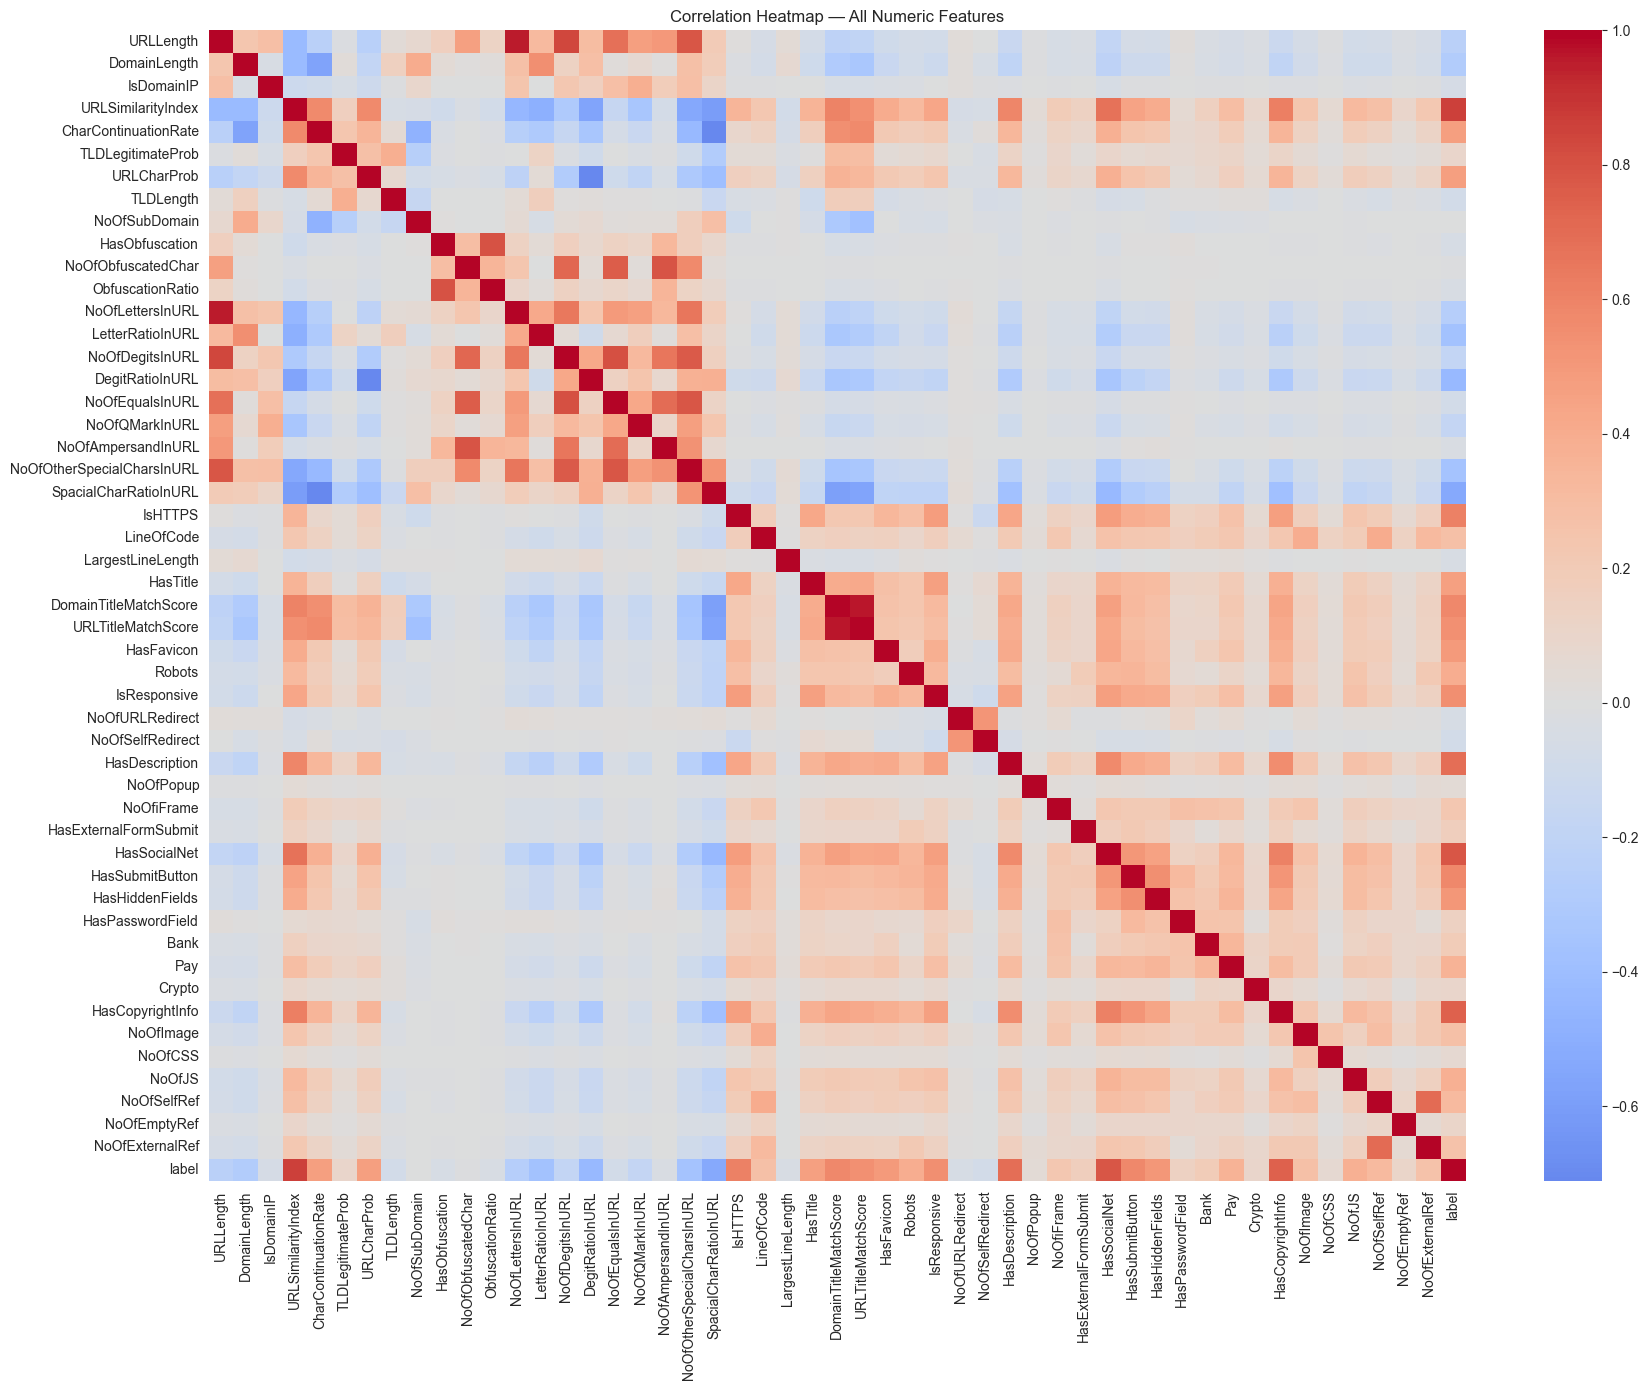

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax)
ax.set_title("Correlation Heatmap — All Numeric Features")
plt.tight_layout()
plt.show()

In [9]:
# Correlation of each feature with the label (sorted)
corr_with_label = corr['label'].drop('label').sort_values(key=abs, ascending=False)
print("Top 15 features most correlated with label:")
corr_with_label.head(15)

Top 15 features most correlated with label:


URLSimilarityIndex       0.860342
HasSocialNet             0.783882
HasCopyrightInfo         0.743197
HasDescription           0.690011
IsHTTPS                  0.610253
DomainTitleMatchScore    0.584204
HasSubmitButton          0.578816
IsResponsive             0.548977
URLTitleMatchScore       0.538844
SpacialCharRatioInURL   -0.533003
HasHiddenFields          0.507715
HasFavicon               0.493607
URLCharProb              0.469521
CharContinuationRate     0.467162
HasTitle                 0.460337
Name: label, dtype: float64

## 6. Columns to Drop Before Modeling

Ye columns identifier/raw-text hain, direct model input ke liye useless ya leakage-prone:
- `FILENAME` — random file identifier
- `URL`, `Domain` — raw text (features already extracted separately)
- `TLD` — raw text (numeric proxies TLDLength, TLDLegitimateProb already exist)
- `Title` — raw scraped text, high cardinality

In [10]:
cols_to_drop = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
print("Remaining feature count after drop:", df.shape[1] - len(cols_to_drop) - 1)  # -1 for label

# Save cleaned dataset for next notebook (02_preprocessing)
df.to_csv("../data/processed/eda_cleaned.csv", index=False)
print("Saved: ../data/processed/eda_cleaned.csv")

Remaining feature count after drop: 50
Saved: ../data/processed/eda_cleaned.csv


## Summary / Observations

Note your observations here after reviewing the EDA — e.g. which features looked like the strongest separators, any surprising patterns, and what to carry into the next notebook (`02_preprocessing.ipynb`).